In [2]:
from pytrends.request import TrendReq
import pandas as pd

## Conectarse a Google Trends
pytrends = TrendReq(hl="es-AR", tz=180)


## Palabras clave a analizar
palabras = [
    "alimentación saludable",
    "productos orgánicos",
    "veganismo",
    "sin TACC",
    "café de especialidad"
]


## Buscar datos de Argentina durante los últimos 5 años
pytrends.build_payload(
    kw_list=palabras,
    timeframe="today 5-y",
    geo="AR"
)


## Obtener la evolución del interés
trends_df = pytrends.interest_over_time()


## Eliminar la columna que no se utiliza
if "isPartial" in trends_df.columns:
    trends_df = trends_df.drop(columns=["isPartial"])


## Mostrar las primeras filas
print(trends_df.head())


## Calcular el interés promedio de cada concepto
print("\nINTERÉS PROMEDIO")
print(trends_df.mean().sort_values(ascending=False))


## Comparar el primer y el último valor para ver si la tendencia creció
print("\nEVOLUCIÓN DE CADA CONCEPTO")

for palabra in palabras:

    inicio = trends_df[palabra].iloc[0]
    fin = trends_df[palabra].iloc[-1]

    if fin > inicio:
        tendencia = "Creció"
    elif fin < inicio:
        tendencia = "Disminuyó"
    else:
        tendencia = "Se mantuvo estable"

    print(f"{palabra}: {tendencia}")


## Guardar los datos en un CSV
trends_df.to_csv(
    "google_trends_argentina.csv",
    encoding="utf-8-sig"
)

print("\nArchivo guardado como google_trends_argentina.csv")




            alimentación saludable  productos orgánicos  veganismo  sin TACC  \
date                                                                           
2021-08-01                       5                    0          2        57   
2021-08-08                       4                    0          3        55   
2021-08-15                       4                    0          3        57   
2021-08-22                       6                    0          4        58   
2021-08-29                       6                    0          3        55   

            café de especialidad  
date                              
2021-08-01                     0  
2021-08-08                     0  
2021-08-15                     0  
2021-08-22                     0  
2021-08-29                     0  

INTERÉS PROMEDIO
sin TACC                  71.362595
alimentación saludable     3.977099
veganismo                  1.068702
café de especialidad       0.812977
productos orgánicos        0.015

In [ ]:
# Resultados: De las palabras analizadas, el mayor interés se mostró en sin TACC y en menor medida alimentación saludable, mientras que veganismo,café de especialidad y productos orgánicos muestran menor interés.

#Tendencias crecientes: sin TACC y café de especialidad.

In [4]:
# Limpieza y deteccion de nulos

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

ruta_googletrends = "C:\\Users\\esteb\\Documents\\Esteban\\CURSOS\\Data-analisis-ComIT_ok\\proyecto-intermedio-okok\\Ecofood-consulting\\data\\raw\\google_trends_argentina.csv"

conexion = sqlite3.connect(ruta_googletrends)
df = pd.read_csv(ruta_googletrends)

#Revisión de nulos y EDA

print(df.isnull().sum())

print(df.dtypes)

print(df.head())

date                      0
alimentación saludable    0
productos orgánicos       0
veganismo                 0
sin TACC                  0
café de especialidad      0
dtype: int64
date                        str
alimentación saludable    int64
productos orgánicos       int64
veganismo                 int64
sin TACC                  int64
café de especialidad      int64
dtype: object
         date  alimentación saludable  productos orgánicos  veganismo  \
0  2021-08-01                       5                    0          2   
1  2021-08-08                       4                    0          3   
2  2021-08-15                       4                    0          3   
3  2021-08-22                       6                    0          4   
4  2021-08-29                       6                    0          3   

   sin TACC  café de especialidad  
0        57                     0  
1        55                     0  
2        57                     0  
3        58                   

In [2]:
# Convertir fecha
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

# Crear columna año-mes
df["anio_mes"] = df["date"].dt.to_period("M")

# Agrupar por año-mes y dar promedio
agrupado = df.groupby("anio_mes").mean().reset_index()
print(agrupado)

#Crear CSV con los datos agrupados
agrupado.to_csv(
    "google_trends_argentina_agrupado.csv",
    encoding="utf-8-sig"
)

   anio_mes                date  alimentación saludable  productos orgánicos  \
0   2021-08 2021-08-15 00:00:00                    5.00                 0.00   
1   2021-09 2021-09-15 12:00:00                    4.75                 0.00   
2   2021-10 2021-10-17 00:00:00                    7.00                 0.00   
3   2021-11 2021-11-17 12:00:00                    8.00                 0.00   
4   2021-12 2021-12-15 12:00:00                    1.75                 0.00   
..      ...                 ...                     ...                  ...   
56  2026-04 2026-04-15 12:00:00                    3.00                 0.25   
57  2026-05 2026-05-17 00:00:00                    3.80                 0.00   
58  2026-06 2026-06-17 12:00:00                    3.25                 0.00   
59  2026-07 2026-07-15 12:00:00                    1.25                 0.00   
60  2026-08 2026-08-02 00:00:00                    2.00                 0.00   

    veganismo  sin TACC  café de especi

# Predicciones

Esperaria que las tendencias generales para todo lo relacionado a alimentacion saludable estuviese en aumento, por la creciente concientización sobre la importancia de la alimentacion y la salud en general, asi como tambien una tendencia creciente hacia las busquedas relacionadas al cafe de especialidad por ser tendencia en los locales comerciales en al acutalidad. POr otro lado, hubiese esperado que se mantuviese estable las busquedas relacionas al veganismo y los alimentos sin TACC al estar más arraigadas a alimentaciones mas restrictivas y de nicho por decirlo de alguna forma.

# Resultados

Los resultados  muestran que las busquedas por términos de veganismo y alimentos saludables han disminuido, mientras que se mantuvo estable para productos orgánicos y en medida creciente para las busquedas de cafeteria de especialidad y alimentos sin TACC.

- Se podría deducir que el aumento en la tendencia de busqueda por las cafeterias de especialidad es por la moda creciente, mientas que los productos sin TACC podría verse en aumento por un deterioro en la salud gastoinstestinal general por los alimentos ultraprocesados o por un mayor interés en el cuidado y precaución de la salud en general, lo que lleva a consultas médicas que pueden llegar a diagnosticos como el celiaquismo, cibo, etc.
- Para las tendencias decrecientes, quizás las busquedas de alimentos saludables han disminuido por algún equivalente o por busquedas más concretas o incluso por una disminución del interés en la sociedad general por la adopcion de una dieta más saludable. En este sentido, menciono sociedad general a la parte de la sociedad que no está introducida en cuestiones nutricionales propiemente dicho, por lo que el término "alimentos saludables" correspondería a una busqueda primaria hacia el acercamiento general a cuestiones nutricionales. Así por su parte, veganismo pudo haber decrecido de igual manera por la disminución de intereés por adoptar este tipo de dieta que hace unos años era más popular.
- Por el lado de porductos orgánicos, al ver la tendencia estable, se podría deducir que 1- el nuevo interés por los productos orgánicos está en crecimiento, al manetenerse estable las busquedas en Google, podríamos imaginar que son las primeras búsquedas hacia un proveedor de este tipo de alimentos; una vez encontrado, las busqueda por usuario son menos frecuentes, por lo que en el global, si se diese esa situación, el intereés sería creciente. 2- Tambíen podría ser que el segmento de consumo de productos orgánicos no tiene un crecimiento relevante para considerarse en crecimiento, sino que es siempre un aproximado de un mismo volumen de consumidores.

In [20]:
ruta_df_agrupado = "C:\\Users\\esteb\\Documents\\Esteban\\CURSOS\\Data-analisis-ComIT_ok\\proyecto-intermedio-okok\\Ecofood-consulting\\data\\processed\\google_trends_argentina_agrupado.csv"
df_agrupado = pd.read_csv(ruta_df_agrupado)

In [23]:
df_agrupado.dtypes

if "date" in df_agrupado.columns:
    df_agrupado = df_agrupado.drop(columns=["date"])



In [24]:
df_agrupado.head()

,Unnamed: 0,anio_mes,alimentación saludable,productos orgánicos,veganismo,sin TACC,café de especialidad
0,0,2021-08,5.00,0.0,3.00,56.40,0.0
1,1,2021-09,4.75,0.0,3.00,51.00,0.5
2,2,2021-10,7.00,0.0,4.60,47.20,0.0
3,3,2021-11,8.00,0.0,3.25,48.50,0.0
4,4,2021-12,1.75,0.0,1.75,53.75,0.0


In [25]:
df_agrupado = df_agrupado.drop(columns=["Unnamed: 0"])

In [26]:
df_agrupado.head()

,anio_mes,alimentación saludable,productos orgánicos,veganismo,sin TACC,café de especialidad
0,2021-08,5.00,0.0,3.00,56.40,0.0
1,2021-09,4.75,0.0,3.00,51.00,0.5
2,2021-10,7.00,0.0,4.60,47.20,0.0
3,2021-11,8.00,0.0,3.25,48.50,0.0
4,2021-12,1.75,0.0,1.75,53.75,0.0


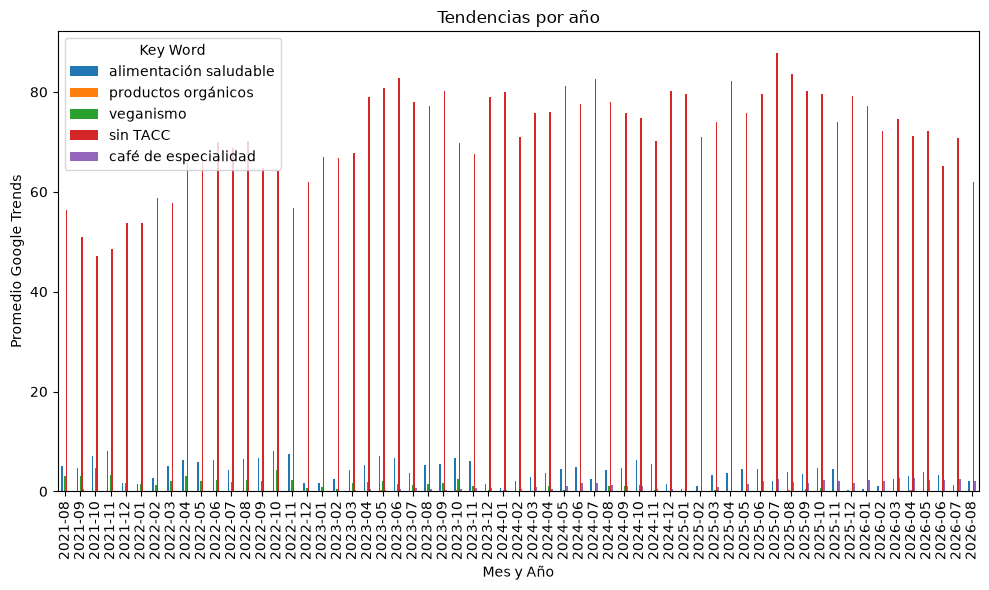

In [30]:
# Gráficos de evolución de tendencias
df_agrupado.plot(
    x="anio_mes", 
    kind="bar", 
    figsize=(10,6)
)
plt.title("Tendencias por año")
plt.xlabel("Mes y Año")
plt.ylabel("Promedio Google Trends")
plt.xticks(rotation=90)
plt.legend(title="Key Word")

plt.tight_layout()
plt.show()